In [1]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("/content/diabetes (1).csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

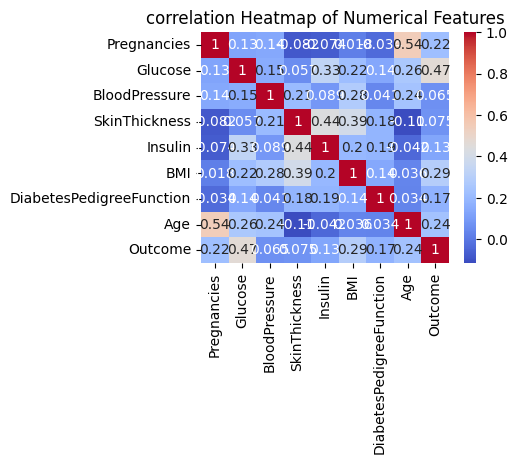

In [7]:
plt.figure(figsize=(4,3))
sns.heatmap(df.corr(numeric_only= True), annot = True, cmap= 'coolwarm')
plt.title("correlation Heatmap of Numerical Features")
plt.show()

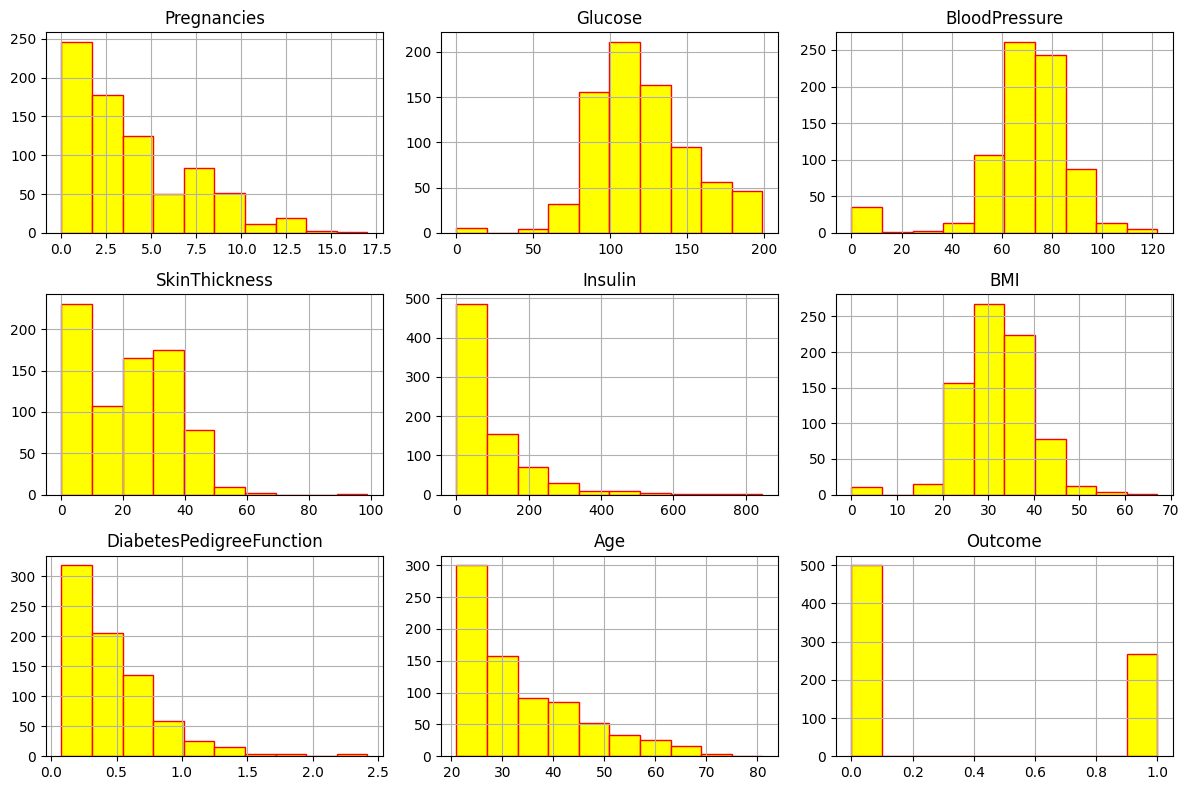

In [8]:
# Histograms for numeric features
df.hist(figsize=(12,8), facecolor="yellow",edgecolor="red")
plt.tight_layout()
plt.show()

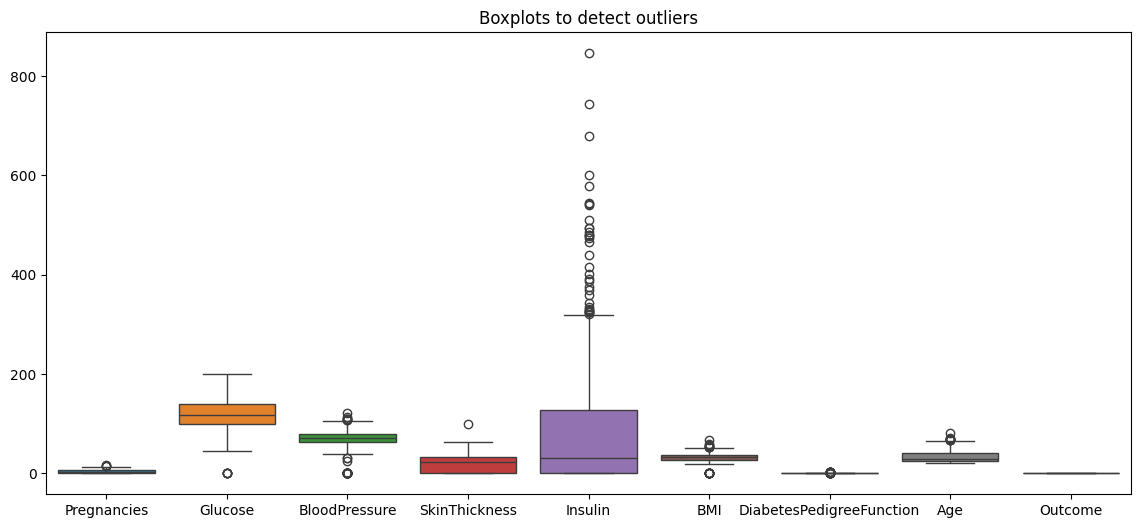

In [9]:
# Boxplots to detect outliers

plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.title("Boxplots to detect outliers")
plt.show()

In [10]:
#Handle missing values (e.g., imputation).
df.isnull().sum()  # In this Dataset no Null vlaue present

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [11]:
#Encode categorical variables.
df.info()   # no categoricali Column Present

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [12]:
#Treat the Outlier
outlier_cols = ['Pregnancies', 'Glucose', 'SkinThickness', 'BMI',	'DiabetesPedigreeFunction']
for colname in outlier_cols:
    q1 = df[colname].quantile(0.25)
    q3 = df[colname].quantile(0.75)
    iqr = q3 - q1
    upper_extreme = q3 + (1.5 * iqr)
    lower_extreme = q1 - (1.5 * iqr)

    df.loc[df[colname] > upper_extreme, colname] = upper_extreme
    df.loc[df[colname] < lower_extreme, colname] = lower_extreme

/tmp/ipython-input-425167405.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '13.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[colname] > upper_extreme, colname] = upper_extreme
/tmp/ipython-input-425167405.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '202.125' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[colname] > upper_extreme, colname] = upper_extreme


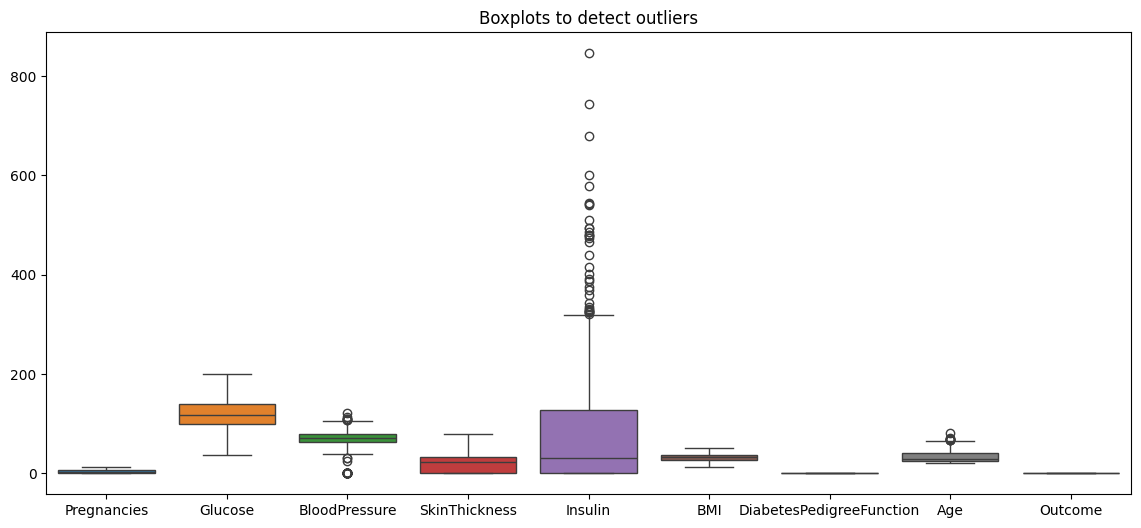

In [13]:
# Boxplots to detect outliers

plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.title("Boxplots to detect outliers")
plt.show()

In [14]:
#Model Building:
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',	'BMI',	'DiabetesPedigreeFunction',	'Age']]
y = df['Outcome']

In [15]:
#Split the Dataset in Train and Test Part
from sklearn.model_selection import train_test_split
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
#Build a logistic regression model using appropriate libraries (e.g., scikit-learn).

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

Lr_pipeline = make_pipeline(StandardScaler(), LogisticRegression())
Lr_pipeline.fit(X_train1, y_train1)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

In [17]:
#Train the model using the training data.
y_train_pred1 = Lr_pipeline.predict(X_train1)
y_test_pred1 = Lr_pipeline.predict(X_test1)

In [18]:
#Model Evaluation:
#Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import recall_score, precision_score, f1_score

In [19]:
#Confusion matrix for Train Data set
conf_matrix = confusion_matrix(y_train1, y_train_pred1)
conf_matrix

array([[356,  45],
       [ 90, 123]])

In [20]:
#Accuracy score for Train Data set
accuracy = accuracy_score(y_train1, y_train_pred1)
print("Accuracy score:", accuracy)

Accuracy score: 0.7801302931596091


In [21]:
# Calculate recall for Train Data set
recall = recall_score(y_train1, y_train_pred1)
print("Recall:", np.round(recall,2))

Recall: 0.58


In [22]:
#Calculate precision for Train Data set
precision = precision_score(y_train1, y_train_pred1)
print("Precision:", np.round(precision,2))

Precision: 0.73


In [23]:
# Calculate F1-score for Train Data set
f1 = f1_score(y_train1, y_train_pred1)
print("F1-score:", np.round(f1,2))

F1-score: 0.65


In [24]:
#Confusion matrix for Teat Data set
conf_matrix = confusion_matrix(y_test1, y_test_pred1)
conf_matrix

array([[79, 20],
       [18, 37]])

In [25]:
#Accuracy score for Teat Data set
accuracy = accuracy_score(y_test1, y_test_pred1)
print("Accuracy score:", accuracy)

Accuracy score: 0.7532467532467533


In [26]:
# Calculate recall for Teat Data set
recall = recall_score(y_test1, y_test_pred1)
print("Recall:", np.round(recall,2))

Recall: 0.67


In [27]:
#Calculate precision for Test Data set
precision = precision_score(y_test1, y_test_pred1)
print("Precision:", np.round(precision,2))

Precision: 0.65


In [28]:
# Calculate F1-score for Test Date set
f1 = f1_score(y_test1, y_test_pred1)
print("F1-score:", np.round(f1,2))

F1-score: 0.66


In [29]:
#Visualize the ROC curve.
from sklearn.metrics import roc_curve, auc

In [30]:
# Predictions on the test set
predictions = Lr_pipeline.predict(X_train1)
y_pred_proba = Lr_pipeline.predict_proba(X_train1)[:,1]

In [31]:
#ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_train1, y_pred_proba)
roc_auc = auc(fpr, tpr)

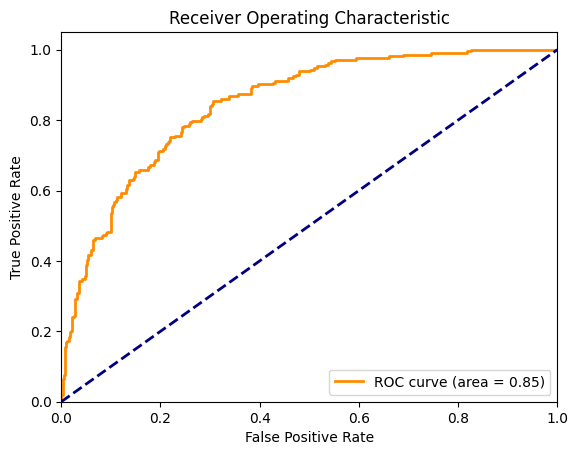

AUC score: 0.846604146909721


In [32]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

print(f"AUC score: {roc_auc}")

In [33]:
#Interpret the coefficients of the logistic regression model.

# extract the model from pipeline
log_reg = Lr_pipeline.named_steps['logisticregression']  # extract the model from pipeline
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0],
})

print(coeff_df)

                    Feature  Coefficient
0               Pregnancies     0.208517
1                   Glucose     1.090920
2             BloodPressure    -0.254290
3             SkinThickness     0.035037
4                   Insulin    -0.213798
5                       BMI     0.764324
6  DiabetesPedigreeFunction     0.274837
7                       Age     0.414869


In [41]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 87.7 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.0
    Uninstalling cachetools-7.0.0:
      Successfully uninstalled cachetools-7.0.0


In [42]:
import pickle

with open("logistic_model.pkl", "wb") as f:
    pickle.dump(Lr_pipeline, f)


In [43]:
%%writefile app.py
import streamlit as st
import pickle
import pandas as pd

# Load trained pipeline
with open("logistic_model.pkl", "rb") as file:
    model = pickle.load(file)

st.title("Diabetes Prediction App")
st.write("Logistic Regression Model Deployment")

pregnancies = st.number_input("Pregnancies", min_value=0, step=1)
glucose = st.number_input("Glucose", min_value=0)
blood_pressure = st.number_input("Blood Pressure", min_value=0)
skin_thickness = st.number_input("Skin Thickness", min_value=0)
insulin = st.number_input("Insulin", min_value=0)
bmi = st.number_input("BMI", min_value=0.0)
dpf = st.number_input("Diabetes Pedigree Function", min_value=0.0)
age = st.number_input("Age", min_value=1)

if st.button("Predict"):
    input_data = pd.DataFrame(
        [[pregnancies, glucose, blood_pressure, skin_thickness,
          insulin, bmi, dpf, age]],
        columns=[
            "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
        ]
    )

    prediction = model.predict(input_data)
    probability = model.predict_proba(input_data)

    if prediction[0] == 1:
        st.error(f"Diabetes Detected (Probability: {probability[0][1]:.2f})")
    else:
        st.success(f"No Diabetes Detected (Probability: {probability[0][0]:.2f})")


Writing app.py


In [35]:
#Discuss the significance of features in predicting the target variable (survival probability in this case).

#Glucose (1.09): The most influential positive predictor.
#                 A higher glucose level significantly increases the likelihood of a positive outcome

#BMI (0.76):  Also a strong positive contributor, suggesting that individuals with higher BMI are more likely to have the condition.

# Interview Questions:

1. What is the difference between precision and recall?
Ans:- Precision means out of all the cases predieted as positive, how many actual positive Recall means out of all actual positive cases, how many did model correctly identify.

2. What is cross-validation, and why is it important in binary classification?
Ans:- Cross-validation is a statistical technique used to evaluate how well a machine learning model generalizes to unseen data. It involves dividing the dataset into multiple subsets, training the model on some folds, and testing it on the remaining fold(s).